In [1]:
!pip install xarray zarr gcsfs fsspec dask cftime intake intake-esm matplotlib seaborn intake



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.7/134.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.4/115.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 3.9 M

In [2]:
# Mount + config (same folder you used before)
from google.colab import drive
from pathlib import Path
drive.mount("/content/drive", force_remount=True)
OUTDIR = Path("/content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist")
OUTDIR.mkdir(parents=True, exist_ok=True)
print("Saving to:", OUTDIR)

Mounted at /content/drive
Saving to: /content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist


In [ ]:


import intake, pandas as pd, numpy as np, xarray as xr
from tqdm.auto import tqdm

# decode-times helper
try:
    from xarray.coding.cftimeindex import CFDatetimeCoder
    _DECODE_TIMES_KW = dict(decode_times=CFDatetimeCoder(use_cftime=True))
except Exception:
    _DECODE_TIMES_KW = dict(use_cftime=True)

STORAGE_OPTS = {"token": "anon"}
PREF = ["r1i1p1f1","r1i1p1f2","r1i1p1f3","r1i1p1f4"]
MAX_YEARS_ABR = 150
DO_ABRUPT = True
STRICT_LAND = True  # set True to require sftlf; raises if missing

# --- your table models
TABLE_MODELS = [
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-CM2-SR5","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-LM","NorESM2-MM","TaiESM1",
    "UKESM1-0-LL"
]

# --- catalog + lookups (day only)
cat = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")
df = cat.df

def _best_one(dfi):
    if dfi.empty: return None
    g = dfi.copy()
    g["pref_rank"] = g["member_id"].apply(lambda m: PREF.index(m) if m in PREF else 999)
    return g.sort_values(["pref_rank","version"], ascending=[True, False]).iloc[0]

def lookup_day(var, exp):
    d = df[(df.variable_id==var)&(df.table_id=="day")&(df.experiment_id==exp)&(df.source_id.isin(TABLE_MODELS))].copy()
    out={}
    for m,sub in d.groupby("source_id"):
        r=_best_one(sub)
        if r is not None:
            out[m]=dict(zstore=r.zstore, model=m, grid=r.grid_label, exp=exp)
    return out

def lookup_fx_sftlf():
    dfx=df[(df.variable_id=="sftlf")&(df.table_id=="fx")].copy(); L={}
    for (m,g),sub in dfx.groupby(["source_id","grid_label"]):
        r=_best_one(sub)
        if r is not None: L[(m,g)]=dict(zstore=r.zstore)
    return L

tas_hist, tas_ssp = lookup_day("tas","historical"), lookup_day("tas","ssp245")
tasmax_hist, tasmax_ssp = lookup_day("tasmax","historical"), lookup_day("tasmax","ssp245")
fx_lookup = lookup_fx_sftlf()
tas_abrt = lookup_day("tas","abrupt-4xCO2") if DO_ABRUPT else {}
tasmax_abrt = lookup_day("tasmax","abrupt-4xCO2") if DO_ABRUPT else {}

# require presence in BOTH historical & ssp245 (var-by-var)
models_tas    = sorted(set(tas_hist)&set(tas_ssp))
models_tasmax = sorted(set(tasmax_hist)&set(tasmax_ssp))
abrupt_tas    = sorted(set(models_tas)&set(tas_abrt)) if DO_ABRUPT else []
abrupt_tasmax = sorted(set(models_tasmax)&set(tasmax_abrt)) if DO_ABRUPT else []

print("Eligible tas:", len(models_tas))
print("Eligible tasmax:", len(models_tasmax))

# --- open / land / weights
def open_zarr(zurl):
    try:
        return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
    except Exception:
        return xr.open_zarr(zurl, consolidated=False, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)

def land_mask(model, grid):
    key=(model,grid)
    if key in fx_lookup:
        ds=open_zarr(fx_lookup[key]["zstore"])
        if "sftlf" in ds:
            m=ds["sftlf"]
            if "time" in m.dims: m=m.isel(time=0)
            return (m>50)
    return None

def _broadcast_land_mask(da, model, grid):
    lm = land_mask(model, grid)
    if lm is None:
        if STRICT_LAND:
            raise RuntimeError(f"No sftlf land mask for {model}[{grid}]")
        return None
    return lm.broadcast_like(da.isel(time=0, drop=True))

def global_weighted(da):
    w=np.cos(np.deg2rad(da["lat"]))
    return da.weighted(w).mean(("lat","lon"), skipna=True)

# --- CORRECT definitions (LAND-MASKED for TDM/TDX):
# TDM = annual max of the daily spatial max of tas (land-only)
def TDM_max_anywhere_tas_day(meta):
    ds  = open_zarr(meta["zstore"])
    tas = ds["tas"].chunk({"time":60})
    lm  = _broadcast_land_mask(tas, meta["model"], meta.get("grid",""))
    if lm is not None:
        tas = tas.where(lm)
    daily_spatial_max = tas.max(("lat","lon"), skipna=True)
    return daily_spatial_max.groupby("time.year").max("time", skipna=True)

# TDX = annual max of the daily spatial max of tasmax (land-only)
def TDX_max_anywhere_tasmax_day(meta):
    ds  = open_zarr(meta["zstore"])
    tmx = ds["tasmax"].chunk({"time":60})
    lm  = _broadcast_land_mask(tmx, meta["model"], meta.get("grid",""))
    if lm is not None:
        tmx = tmx.where(lm)
    daily_spatial_max = tmx.max(("lat","lon"), skipna=True)
    return daily_spatial_max.groupby("time.year").max("time", skipna=True)

# TTL = tropical land (45S–45N) annual mean (land-only)
def TTL_tropical_land_tas_day(meta):
    ds  = open_zarr(meta["zstore"])
    tas = ds["tas"].sel(lat=slice(-45,45)).chunk({"time":60})
    lm  = land_mask(meta["model"], meta.get("grid",""))
    if lm is not None:
        lm = lm.sel(lat=slice(-45,45)).broadcast_like(tas.isel(time=0, drop=True))
        tas = tas.where(lm)
    gm = global_weighted(tas)
    return gm.groupby("time.year").mean("time", skipna=True)

def save_da(da, path, trim=None):
    if trim is not None:
        da = da.isel(year=slice(0,trim))
    np.save(path, da.compute().values)  # np.save overwrites existing files

# ---- SSP245 recompute (overwrite existing files)
print("\nRecomputing SSP245 (spatial MAX for TDM/TDX)…")
saved={"TDM":0,"TDX":0,"TTL":0}
for m in tqdm(models_tas, desc="tas → TDM/TTL"):
    try:
        save_da(TDM_max_anywhere_tas_day(tas_ssp[m]), OUTDIR / f"{m}_ssp245_TDM.npy"); saved["TDM"]+=1
    except Exception as e:
        print("  TDM fail", m, e)
    try:
        save_da(TTL_tropical_land_tas_day(tas_ssp[m]), OUTDIR / f"{m}_ssp245_TTL.npy"); saved["TTL"]+=1
    except Exception as e:
        print("  TTL fail", m, e)

for m in tqdm(models_tasmax, desc="tasmax → TDX"):
    try:
        save_da(TDX_max_anywhere_tasmax_day(tasmax_ssp[m]), OUTDIR / f"{m}_ssp245_TDX.npy"); saved["TDX"]+=1
    except Exception as e:
        print("  TDX fail", m, e)

print("SSP245 saved:", saved)

# ---- abrupt (same models, when available)
if DO_ABRUPT:
    print("\nRecomputing abrupt-4xCO2 (spatial MAX for TDM/TDX)…")
    saved_ab={"TDM":0,"TDX":0,"TTL":0}
    for m in tqdm(abrupt_tas, desc="abrupt tas → TDM/TTL"):
        try:
            save_da(TDM_max_anywhere_tas_day(tas_abrt[m]), OUTDIR / f"{m}_abrupt-4xCO2_TDM.npy", trim=MAX_YEARS_ABR); saved_ab["TDM"]+=1
        except Exception as e:
            print("  TDM fail", m, e)
        try:
            save_da(TTL_tropical_land_tas_day(tas_abrt[m]), OUTDIR / f"{m}_abrupt-4xCO2_TTL.npy", trim=MAX_YEARS_ABR); saved_ab["TTL"]+=1
        except Exception as e:
            print("  TTL fail", m, e)
    for m in tqdm(abrupt_tasmax, desc="abrupt tasmax → TDX"):
        try:
            save_da(TDX_max_anywhere_tasmax_day(tasmax_abrt[m]), OUTDIR / f"{m}_abrupt-4xCO2_TDX.npy", trim=MAX_YEARS_ABR); saved_ab["TDX"]+=1
        except Exception as e:
            print("  TDX fail", m, e)
    print("abrupt saved:", saved_ab)


Mounted at /content/drive
Saving to: /content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist
Eligible tas: 24
Eligible tasmax: 19

Recomputing SSP245 (spatial MAX for TDM/TDX)…


tas → TDM/TTL:   0%|          | 0/24 [00:00<?, ?it/s]

/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDateti

  TDM fail EC-Earth3-CC No sftlf land mask for EC-Earth3-CC[gr]


/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDateti

...

abrupt tasmax → TDX:   0%|          | 0/15 [00:00<?, ?it/s]

/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDateti

  TDX fail NorESM2-LM No sftlf land mask for NorESM2-LM[gn]


/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDateti

abrupt saved: {'TDM': 18, 'TDX': 14, 'TTL': 21}


In [ ]:

# =========================
# Imports
# =========================
import intake, pandas as pd, numpy as np, xarray as xr, cftime
from tqdm.auto import tqdm

# =========================
# Globals / preferences
# =========================
STORAGE_OPTS = {"token": "anon"}
PREF         = ["r1i1p1f1","r1i1p1f2","r1i1p1f3","r1i1p1f4"]
MAX_YEARS_ABR = 150
DO_ABRUPT     = True
STRICT_LAND   = True  # True => raise if sftlf (land mask) is missing

TABLE_MODELS = [
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-CM2-SR5","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-LM","NorESM2-MM","TaiESM1","UKESM1-0-LL"
]

# =========================
# Catalog + lookups
# =========================
cat = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")
df = cat.df

def _best_one(dfi):
    if dfi.empty: return None
    g = dfi.copy()
    g["pref_rank"] = g["member_id"].apply(lambda m: PREF.index(m) if m in PREF else 999)
    return g.sort_values(["pref_rank","version"], ascending=[True, False]).iloc[0]

def lookup_day(var, exp):
    d = df[(df.variable_id==var)&(df.table_id=="day")&(df.experiment_id==exp)&(df.source_id.isin(TABLE_MODELS))].copy()
    out={}
    for m,sub in d.groupby("source_id"):
        r=_best_one(sub)
        if r is not None:
            out[m]=dict(zstore=r.zstore, model=m, grid=r.grid_label, exp=exp)
    return out

def lookup_fx_sftlf():
    dfx=df[(df.variable_id=="sftlf")&(df.table_id=="fx")].copy()
    L={}
    for (m,g),sub in dfx.groupby(["source_id","grid_label"]):
        r=_best_one(sub)
        if r is not None:
            L[(m,g)]=dict(zstore=r.zstore)
    return L

fx_lookup = lookup_fx_sftlf()

# =========================
# Robust open + year extractor
# =========================
try:
    from xarray import coders as _xr_coders
    _DECODER = dict(decode_times=_xr_coders.CFDatetimeCoder(use_cftime=True))
except Exception:
    _DECODER = dict(decode_times=True)

def open_zarr_robust(zurl):
    try:
        ds = xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODER)
    except Exception:
        ds = xr.open_zarr(zurl, consolidated=False, storage_options=STORAGE_OPTS, **_DECODER)
    if "time" in ds.coords:
        try:
            _ = ds["time"].dt.year
        except Exception:
            try:
                ds = xr.decode_cf(ds, use_cftime=True)
            except Exception:
                pass
    return ds

def years_from_time_ultra(ds):
    """
    Derive a 'year' array aligned to time for:
      - numpy/cftime datetimes (dt.year)
      - object arrays of datetime-like
      - numeric time w/ CF units on time or time bounds
      - numeric 'time' that's already years
    """
    if "time" not in ds.coords:
        raise ValueError("Dataset has no 'time' coordinate.")
    t = ds["time"]

    # 1) datetime-like
    try:
        return xr.DataArray(t.dt.year, name="year", dims=t.dims, coords=t.coords)
    except Exception:
        pass

    vals = np.asarray(t.values)

    # 2) object array of datetime-like
    if vals.dtype == object:
        yrs = np.array([getattr(v, "year", np.nan) for v in vals], dtype=float)
        if np.isfinite(yrs).any():
            if np.isnan(yrs).any():
                idx = np.arange(yrs.size)
                m = np.isfinite(yrs)
                yrs[~m] = np.interp(idx[~m], idx[m], yrs[m])
            return xr.DataArray(yrs.astype(int), name="year", dims=t.dims, coords=t.coords)

    # 3) numeric with CF units on time
    units = t.attrs.get("units")
    cal = t.attrs.get("calendar", "standard")
    if units:
        dts = cftime.num2date(vals, units, calendar=cal,
                              only_use_cftime_datetimes=True, only_use_python_datetimes=False)
        yrs = np.array([d.year for d in dts], dtype=int)
        return xr.DataArray(yrs, name="year", dims=t.dims, coords=t.coords)

    # 4) units on time bounds
    for bname in ("time_bnds","time_bounds","time_bnd"):
        if bname in ds.variables:
            tb = ds[bname]
            tu = tb.attrs.get("units") or ds.attrs.get("time_units")
            tcal = tb.attrs.get("calendar", cal)
            if tu and "time" in tb.dims:
                mid = tb.mean(dim=[d for d in tb.dims if d != "time"] or tb.dims[-1])
                dts = cftime.num2date(np.asarray(mid.values), tu, calendar=tcal,
                                      only_use_cftime_datetimes=True, only_use_python_datetimes=False)
                yrs = np.array([d.year for d in dts], dtype=int)
                return xr.DataArray(yrs, name="year", dims=("time",), coords={"time": ds["time"]})

    # 5) numeric 'time' already years
    if np.issubdtype(vals.dtype, np.number):
        vmin = np.nanmin(vals); vmax = np.nanmax(vals)
        if 0 < vmin < 3000 and vmax < 3000:
            return xr.DataArray(vals.astype(int), name="year", dims=t.dims, coords=t.coords)

    raise TypeError(f"Cannot derive years from time; dtype={t.dtype}, units={units}, calendar={cal}")

# =========================
# Land mask + helpers
# =========================
def land_mask(model, grid):
    key=(model,grid)
    if key in fx_lookup:
        ds = open_zarr_robust(fx_lookup[key]["zstore"])
        if "sftlf" in ds:
            m = ds["sftlf"]
            if "time" in m.dims:
                m = m.isel(time=0)
            return (m > 50)  # boolean land mask
    return None

def _broadcast_land_mask(da, model, grid):
    lm = land_mask(model, grid)
    if lm is None:
        if STRICT_LAND:
            raise RuntimeError(f"No sftlf land mask for {model}[{grid}]")
        return None
    return lm.broadcast_like(da.isel(time=0, drop=True))

def global_weighted(da):
    w = np.cos(np.deg2rad(da["lat"]))
    return da.weighted(w).mean(("lat","lon"), skipna=True)

# =========================
# Metrics (LAND-MASKED TDM/TDX; TTL is land-only)
# =========================
# TDM = annual max of daily spatial max of tas (land-only)
def TDM_max_anywhere_tas_day(meta):
    ds  = open_zarr_robust(meta["zstore"])
    tas = ds["tas"].chunk({"time": 60})
    lm  = _broadcast_land_mask(tas, meta["model"], meta.get("grid",""))
    if lm is not None:
        tas = tas.where(lm)
    daily_spatial_max = tas.max(("lat","lon"), skipna=True)
    years = years_from_time_ultra(ds)
    return daily_spatial_max.groupby(years).max("time", skipna=True)

# TDX = annual max of daily spatial max of tasmax (land-only)
def TDX_max_anywhere_tasmax_day(meta):
    ds  = open_zarr_robust(meta["zstore"])
    tmx = ds["tasmax"].chunk({"time": 60})
    lm  = _broadcast_land_mask(tmx, meta["model"], meta.get("grid",""))
    if lm is not None:
        tmx = tmx.where(lm)
    daily_spatial_max = tmx.max(("lat","lon"), skipna=True)
    years = years_from_time_ultra(ds)
    return daily_spatial_max.groupby(years).max("time", skipna=True)

# TTL = tropical land (45S–45N) annual mean (land-only)
def TTL_tropical_land_tas_day(meta):
    ds  = open_zarr_robust(meta["zstore"])
    tas = ds["tas"].sel(lat=slice(-45,45)).chunk({"time": 60})
    lm  = land_mask(meta["model"], meta.get("grid",""))
    if lm is not None:
        lm = lm.sel(lat=slice(-45,45)).broadcast_like(tas.isel(time=0, drop=True))
        tas = tas.where(lm)
    gm = global_weighted(tas)
    years = years_from_time_ultra(ds)
    return gm.groupby(years).mean("time", skipna=True)

def save_da(da, path, trim=None):
    if trim is not None:
        da = da.isel(year=slice(0, trim))
    np.save(path, da.compute().values)  # overwrites existing files

# =========================
# LOOKUPS for experiments
# =========================
tas_hist     = lookup_day("tas","historical")
tas_ssp      = lookup_day("tas","ssp245")
tasmax_hist  = lookup_day("tasmax","historical")
tasmax_ssp   = lookup_day("tasmax","ssp245")

tas_abrt     = lookup_day("tas","abrupt-4xCO2")      if DO_ABRUPT else {}
tasmax_abrt  = lookup_day("tasmax","abrupt-4xCO2")   if DO_ABRUPT else {}

# Require presence in BOTH historical & ssp245
models_tas    = sorted(set(tas_hist) & set(tas_ssp))
models_tasmax = sorted(set(tasmax_hist) & set(tasmax_ssp))
abrupt_tas    = sorted(set(models_tas) & set(tas_abrt))      if DO_ABRUPT else []
abrupt_tasmax = sorted(set(models_tasmax) & set(tasmax_abrt)) if DO_ABRUPT else []

print("Eligible tas for SSP245:", len(models_tas))
print("Eligible tasmax for SSP245:", len(models_tasmax))

# =========================
# SSP245 recompute (overwrite)
# =========================
print("\nRecomputing SSP245 (land-masked TDM/TDX, TTL)…")
saved = {"TDM":0,"TDX":0,"TTL":0}

for m in tqdm(models_tas, desc="tas → TDM/TTL"):
    try:
        save_da(TDM_max_anywhere_tas_day(tas_ssp[m]), OUTDIR / f"{m}_ssp245_TDM.npy")
        saved["TDM"] += 1
    except Exception as e:
        print("  TDM fail", m, e)
    try:
        save_da(TTL_tropical_land_tas_day(tas_ssp[m]), OUTDIR / f"{m}_ssp245_TTL.npy")
        saved["TTL"] += 1
    except Exception as e:
        print("  TTL fail", m, e)

for m in tqdm(models_tasmax, desc="tasmax → TDX"):
    try:
        save_da(TDX_max_anywhere_tasmax_day(tasmax_ssp[m]), OUTDIR / f"{m}_ssp245_TDX.npy")
        saved["TDX"] += 1
    except Exception as e:
        print("  TDX fail", m, e)

print("SSP245 saved:", saved)

# =========================
# abrupt-4xCO2 recompute (overwrite, trim to first MAX_YEARS_ABR years)
# =========================
if DO_ABRUPT:
    print("\nRecomputing abrupt-4xCO2 (land-masked TDM/TDX, TTL)…")
    saved_ab = {"TDM":0,"TDX":0,"TTL":0}

    for m in tqdm(abrupt_tas, desc="abrupt tas → TDM/TTL"):
        try:
            save_da(TDM_max_anywhere_tas_day(tas_abrt[m]), OUTDIR / f"{m}_abrupt-4xCO2_TDM.npy", trim=MAX_YEARS_ABR)
            saved_ab["TDM"] += 1
        except Exception as e:
            print("  TDM fail", m, e)
        try:
            save_da(TTL_tropical_land_tas_day(tas_abrt[m]), OUTDIR / f"{m}_abrupt-4xCO2_TTL.npy", trim=MAX_YEARS_ABR)
            saved_ab["TTL"] += 1
        except Exception as e:
            print("  TTL fail", m, e)

    for m in tqdm(abrupt_tasmax, desc="abrupt tasmax → TDX"):
        try:
            save_da(TDX_max_anywhere_tasmax_day(tasmax_abrt[m]), OUTDIR / f"{m}_abrupt-4xCO2_TDX.npy", trim=MAX_YEARS_ABR)
            saved_ab["TDX"] += 1
        except Exception as e:
            print("  TDX fail", m, e)

    print("abrupt saved:", saved_ab)

# =========================
# piControl recompute (overwrite)
# =========================
print("\nRecomputing piControl (land-masked TDM/TDX, TTL)…")
tas_pic    = lookup_day("tas", "piControl")
tasmax_pic = lookup_day("tasmax", "piControl")
pi_common  = sorted(set(tas_pic) & set(tasmax_pic))
print("piControl models with tas & tasmax:", len(pi_common))

# Optional: clean zero-byte stale files
for m in pi_common:
    for metric in ("TDM","TTL","TDX"):
        p = OUTDIR / f"{m}_piControl_{metric}.npy"
        if p.exists() and p.stat().st_size == 0:
            p.unlink()

saved_pi = {"TDM":0,"TDX":0,"TTL":0}
for m in tqdm(pi_common, desc="piControl models"):
    try:
        save_da(TDM_max_anywhere_tas_day(tas_pic[m]), OUTDIR / f"{m}_piControl_TDM.npy")
        saved_pi["TDM"] += 1
    except Exception as e:
        print("  TDM fail", m, e)
    try:
        save_da(TTL_tropical_land_tas_day(tas_pic[m]), OUTDIR / f"{m}_piControl_TTL.npy")
        saved_pi["TTL"] += 1
    except Exception as e:
        print("  TTL fail", m, e)
    try:
        save_da(TDX_max_anywhere_tasmax_day(tasmax_pic[m]), OUTDIR / f"{m}_piControl_TDX.npy")
        saved_pi["TDX"] += 1
    except Exception as e:
        print("  TDX fail", m, e)

print("piControl saved:", saved_pi)

# =========================
# Quick optional mask report (abrupt / piControl)
# =========================
def _mask_report(model_list, meta_lookup):
    used, missing = [], []
    for m in model_list:
        lm = land_mask(m, meta_lookup[m].get("grid",""))
        (used if lm is not None else missing).append(m)
    return used, missing

if DO_ABRUPT and abrupt_tas:
    u, mi = _mask_report(abrupt_tas, tas_abrt)
    print(f"\n[abrupt] land-mask present for {len(u)} models.", "Missing:", len(mi))
if pi_common:
    u, mi = _mask_report(pi_common, tas_pic)
    print(f"[piControl] land-mask present for {len(u)} models.", "Missing:", len(mi))


Eligible tas for SSP245: 24
Eligible tasmax for SSP245: 19

Recomputing SSP245 (land-masked TDM/TDX, TTL)…


tas → TDM/TTL:   0%|          | 0/24 [00:00<?, ?it/s]

/tmp/ipython-input-2263384984.py:74: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.decode_cf(ds, use_cftime=True)


KeyboardInterrupt: 

In [ ]:
# ---------------- Colab: mount + load all dictionaries + plot ----------------
# 0) Mount Drive and set OUTDIR (must match where you saved .npy files earlier)
from google.colab import drive
from pathlib import Path
drive.mount("/content/drive", force_remount=True)

OUTDIR = Path("/content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist")
print("Reading from:", OUTDIR)

# 1) Helpers to load files like "<model>_<exp>_<metric>.npy" into dicts
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
from matplotlib import gridspec

def load_metric(exp: str, metric: str) -> dict:
    """
    Return dict: {model_name: numpy_array} for files:
      <model>_<exp>_<metric>.npy within OUTDIR
    """
    d = {}
    for p in OUTDIR.glob(f"*_{exp}_{metric}.npy"):
        # strip "_<exp>_<metric>.npy"
        model = p.name[:-4].rsplit("_", 2)[0]
        d[model] = np.load(p)
    return d

# 2) Load ALL dictionaries
# --- SSP245 (time series 2015–2099 ideally length 85)
TTL_s = load_metric("ssp245", "TTL")
TDM_s = load_metric("ssp245", "TDM")
TDX_s = load_metric("ssp245", "TDX")

# --- Abrupt 4xCO2 (time series; we'll average last 30)
TTL_a = load_metric("abrupt-4xCO2", "TTL")
TDM_a = load_metric("abrupt-4xCO2", "TDM")
TDX_a = load_metric("abrupt-4xCO2", "TDX")

# --- piControl (climatology over full series)
TTL_p = load_metric("piControl", "TTL")
TDM_p = load_metric("piControl", "TDM")
TDX_p = load_metric("piControl", "TDX")

print("Counts (files found):")
print("  SSP245 → TTL:", len(TTL_s), "TDM:", len(TDM_s), "TDX:", len(TDX_s))
print("  4xCO2  → TTL:", len(TTL_a), "TDM:", len(TDM_a), "TDX:", len(TDX_a))
print("  piCtrl → TTL:", len(TTL_p), "TDM:", len(TDM_p), "TDX:", len(TDX_p))


Mounted at /content/drive
Reading from: /content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist
Counts (files found):
  SSP245 → TTL: 36 TDM: 36 TDX: 30
  4xCO2  → TTL: 25 TDM: 25 TDX: 17
  piCtrl → TTL: 29 TDM: 29 TDX: 23


In [ ]:
# ===================== HIST(2005–2014) + SSP245 CONCAT (LAND-ONLY) =====================
import intake, xarray as xr, numpy as np
from pathlib import Path

# ---------------- Configuration ----------------
REFERENCE_PERIOD = (2005, 2014)   # anomaly baseline (all-historical)
SSP_START = 2015
OUTDIR = Path("./cmip6_metrics_concat")   # where npy files will be saved
OUTDIR.mkdir(parents=True, exist_ok=True)

STORAGE_OPTS = {"token": "anon"}
PREF = ["r1i1p1f1","r1i1p1f2","r1i1p1f3","r1i1p1f4"]
STRICT_LAND = True  # require sftlf to mask land

# Allowed models (same as your table)
TABLE_MODELS = [
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-CM2-SR5","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-LM","NorESM2-MM","TaiESM1","UKESM1-0-LL"
]

# ---------------- Catalog ----------------
cat = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")
df = cat.df

def _best_one(dfi):
    if dfi.empty: return None
    g = dfi.copy()
    g["pref_rank"] = g["member_id"].apply(lambda m: PREF.index(m) if m in PREF else 999)
    return g.sort_values(["pref_rank","version"], ascending=[True, False]).iloc[0]

# Pair historical+ssp245, preferring the SAME member_id when possible
def paired_lookup_day(var, models=None, exp_hist="historical", exp_ssp="ssp245"):
    d_hist = df[(df.variable_id==var)&(df.table_id=="day")&(df.experiment_id==exp_hist)&
                (df.source_id.isin(TABLE_MODELS if models is None else models))].copy()
    d_ssp  = df[(df.variable_id==var)&(df.table_id=="day")&(df.experiment_id==exp_ssp)&
                (df.source_id.isin(TABLE_MODELS if models is None else models))].copy()
    out = {}
    for m in sorted(set(d_hist.source_id) & set(d_ssp.source_id)):
        H = d_hist[d_hist.source_id==m].copy()
        S = d_ssp [d_ssp .source_id==m].copy()
        # try to keep the same member
        overlap = sorted(set(H.member_id) & set(S.member_id),
                         key=lambda r: (PREF.index(r) if r in PREF else 999, r))
        if overlap:
            mem = overlap[0]
            hrow = H[H.member_id==mem].sort_values(["version"], ascending=False).iloc[0]
            srow = S[S.member_id==mem].sort_values(["version"], ascending=False).iloc[0]
        else:
            hrow = _best_one(H); srow = _best_one(S)
        out[m] = dict(
            model=m,
            hist=dict(zstore=hrow.zstore, model=m, grid=hrow.grid_label, member=hrow.member_id, exp=exp_hist),
            ssp =dict(zstore=srow.zstore, model=m, grid=srow.grid_label, member=srow.member_id, exp=exp_ssp),
        )
    return out

pairs_tas    = paired_lookup_day("tas",    TABLE_MODELS)
pairs_tasmax = paired_lookup_day("tasmax", TABLE_MODELS)

# ---------------- I/O helpers ----------------
def open_zarr(zurl):
    # consolidated first; fall back if needed; cftime-safe decode
    try:
        return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
    except Exception:
        return xr.open_zarr(zurl, consolidated=False, storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)

# ---------------- Land mask ----------------
def _fx_lookup():
    dfx = df[(df.variable_id=="sftlf")&(df.table_id=="fx")].copy()
    L = {}
    for (m,g), sub in dfx.groupby(["source_id","grid_label"]):
        r = _best_one(sub)
        if r is not None: L[(m,g)] = dict(zstore=r.zstore)
    return L

FX = _fx_lookup()

def land_mask(model, grid):
    key=(model,grid)
    if key in FX:
        ds=open_zarr(FX[key]["zstore"])
        if "sftlf" in ds:
            m = ds["sftlf"]
            if "time" in m.dims: m = m.isel(time=0)
            return (m>50)
    return None

def _broadcast_land_mask(da, model, grid):
    lm = land_mask(model, grid)
    if lm is None:
        if STRICT_LAND:
            raise RuntimeError(f"No sftlf land mask for {model}[{grid}]")
        return None
    return lm.broadcast_like(da.isel(time=0, drop=True))

def global_weighted(da):
    w = np.cos(np.deg2rad(da["lat"]))
    return da.weighted(w).mean(("lat","lon"), skipna=True)

# ---------------- Metric definitions (same as your corrected ones) ----------------
# TDM = annual max of the daily spatial max of tas (land-only)
def TDM_max_anywhere_tas_day(meta):
    ds  = open_zarr(meta["zstore"])
    tas = ds["tas"].chunk({"time":60})
    lm  = _broadcast_land_mask(tas, meta["model"], meta.get("grid",""))
    if lm is not None:
        tas = tas.where(lm)
    daily_spatial_max = tas.max(("lat","lon"), skipna=True)
    return daily_spatial_max.groupby("time.year").max("time", skipna=True).rename({"year":"year"})

# TDX = annual max of the daily spatial max of tasmax (land-only)
def TDX_max_anywhere_tasmax_day(meta):
    ds  = open_zarr(meta["zstore"])
    tmx = ds["tasmax"].chunk({"time":60})
    lm  = _broadcast_land_mask(tmx, meta["model"], meta.get("grid",""))
    if lm is not None:
        tmx = tmx.where(lm)
    daily_spatial_max = tmx.max(("lat","lon"), skipna=True)
    return daily_spatial_max.groupby("time.year").max("time", skipna=True).rename({"year":"year"})

# TTL = tropical land (45S–45N) annual mean (land-only)
def TTL_tropical_land_tas_day(meta):
    ds  = open_zarr(meta["zstore"])
    tas = ds["tas"].sel(lat=slice(-45,45)).chunk({"time":60})
    lm  = land_mask(meta["model"], meta.get("grid",""))
    if lm is not None:
        lm = lm.sel(lat=slice(-45,45)).broadcast_like(tas.isel(time=0, drop=True))
        tas = tas.where(lm)
    gm = global_weighted(tas)
    return gm.groupby("time.year").mean("time", skipna=True).rename({"year":"year"})

# ---------------- Concat logic ----------------
def _hist_tail(da, start=2005, end=2014):
    # da has "year" coordinate
    return da.sel(year=slice(start, end))

def _ssp_keep(da, start=SSP_START):
    return da.sel(year=slice(start, None))

def concat_hist_then_ssp(metric_fn, meta_hist, meta_ssp, hist_window=(2005,2014), ssp_start=SSP_START):
    # compute annual metric for each experiment
    yH = metric_fn(meta_hist)
    yS = metric_fn(meta_ssp)
    if "year" not in yH.coords: yH = yH.rename({"time":"year"})
    if "year" not in yS.coords: yS = yS.rename({"time":"year"})
    tail = _hist_tail(yH, *hist_window)
    ssp  = _ssp_keep(yS, start=ssp_start)
    combined = xr.concat([tail, ssp], dim="year")
    return combined

def _save_vec_and_years(da, path_base):
    # da: 1D over 'year'
    np.save(path_base + ".npy", da.compute().values)
    np.save(path_base + "_years.npy", da["year"].values.astype(int))

# ---------------- Build & save for all models ----------------
saved = {"TTL":0,"TDM":0,"TDX":0}

for m, pair in pairs_tas.items():
    try:
        ttl = concat_hist_then_ssp(TTL_tropical_land_tas_day, pair["hist"], pair["ssp"],
                                   hist_window=(2005,2014), ssp_start=SSP_START)
        _save_vec_and_years(ttl, str(OUTDIR / f"{m}_hist2005-2014+ssp245_TTL"))
        saved["TTL"] += 1

        tdm = concat_hist_then_ssp(TDM_max_anywhere_tas_day, pair["hist"], pair["ssp"],
                                   hist_window=(2005,2014), ssp_start=SSP_START)
        _save_vec_and_years(tdm, str(OUTDIR / f"{m}_hist2005-2014+ssp245_TDM"))
        saved["TDM"] += 1
    except Exception as e:
        print("TTL/TDM fail", m, e)

for m, pair in pairs_tasmax.items():
    try:
        tdx = concat_hist_then_ssp(TDX_max_anywhere_tasmax_day, pair["hist"], pair["ssp"],
                                   hist_window=(2005,2014), ssp_start=SSP_START)
        _save_vec_and_years(tdx, str(OUTDIR / f"{m}_hist2005-2014+ssp245_TDX"))
        saved["TDX"] += 1
    except Exception as e:
        print("TDX fail", m, e)

print("Saved counts:", saved)

# ---------------- Optional: quick loader for your plotting dicts ----------------
def load_concat_series(kind):  # kind in {"TTL","TDM","TDX"}
    d = {}
    for p in OUTDIR.glob(f"*hist2005-2014+ssp245_{kind}.npy"):
        model = p.name.split("_hist2005-2014+ssp245_")[0]
        d[model] = np.load(p)
    return d

def load_concat_years(kind):
    y = {}
    for p in OUTDIR.glob(f"*hist2005-2014+ssp245_{kind}_years.npy"):
        model = p.name.split("_hist2005-2014+ssp245_")[0]
        y[model] = np.load(p)
    return y

# Example usage in your figure code:
# TTL_s = load_concat_series("TTL"); TDM_s = load_concat_series("TDM"); TDX_s = load_concat_series("TDX")
# YEARS  = load_concat_years("TTL")  # each model has its own years vector starting 2005
# Set REFERENCE_PERIOD = (2005, 2014) and use the per-model years if you want exact alignment.


/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is d

TTL/TDM fail EC-Earth3-CC No sftlf land mask for EC-Earth3-CC[gr]


/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is d

TTL/TDM fail IITM-ESM No sftlf land mask for IITM-ESM[gn]


/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is d

...

TDX fail EC-Earth3-CC No sftlf land mask for EC-Earth3-CC[gr]


/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is d

TDX fail NorESM2-LM No sftlf land mask for NorESM2-LM[gn]


/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is d

Saved counts: {'TTL': 24, 'TDM': 21, 'TDX': 17}


In [3]:
# ---------------- Colab: mount + load all dictionaries + plot ----------------
# 0) Mount Drive and set OUTDIR (must match where you saved .npy files earlier)
from google.colab import drive
from pathlib import Path
drive.mount("/content/drive", force_remount=True)

OUTDIR = Path("/content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist")
print("Reading from:", OUTDIR)

# 1) Helpers to load files like "<model>_<exp>_<metric>.npy" into dicts
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
from matplotlib import gridspec

def load_metric(exp: str, metric: str) -> dict:
    """
    Return dict: {model_name: numpy_array} for files:
      <model>_<exp>_<metric>.npy within OUTDIR
    """
    d = {}
    for p in OUTDIR.glob(f"*_{exp}_{metric}.npy"):
        # strip "_<exp>_<metric>.npy"
        model = p.name[:-4].rsplit("_", 2)[0]
        d[model] = np.load(p)
    return d

# 2) Load ALL dictionaries
# --- SSP245 (time series 2015–2099 ideally length 85)
TTL_s = load_metric("ssp245", "TTL")
TDM_s = load_metric("ssp245", "TDM")
TDX_s = load_metric("ssp245", "TDX")

# --- Abrupt 4xCO2 (time series; we'll average last 30)
TTL_a = load_metric("abrupt-4xCO2", "TTL")
TDM_a = load_metric("abrupt-4xCO2", "TDM")
TDX_a = load_metric("abrupt-4xCO2", "TDX")

# --- piControl (climatology over full series)
TTL_p = load_metric("piControl", "TTL")
TDM_p = load_metric("piControl", "TDM")
TDX_p = load_metric("piControl", "TDX")

print("Counts (files found):")
print("  SSP245 → TTL:", len(TTL_s), "TDM:", len(TDM_s), "TDX:", len(TDX_s))
print("  4xCO2  → TTL:", len(TTL_a), "TDM:", len(TDM_a), "TDX:", len(TDX_a))
print("  piCtrl → TTL:", len(TTL_p), "TDM:", len(TDM_p), "TDX:", len(TDX_p))

Mounted at /content/drive
Reading from: /content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist
Counts (files found):
  SSP245 → TTL: 36 TDM: 36 TDX: 30
  4xCO2  → TTL: 25 TDM: 25 TDX: 17
  piCtrl → TTL: 29 TDM: 29 TDX: 23


Loaded counts for SSP panels (a,b):
  TTL: 24 expected ~36 (if files exist)
  TDM: 21 expected ~36 (if files exist)
  TDX: 17 expected ~30 (if files exist)
Loaded counts for equilibrium panel (c) AFTER matching abrupt∩piControl:
  TTL: 17
  TDM: 17
  TDX: 17
[Panel c] TDM models with ΔT_eq > 12.0°C: ['MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'NorESM2-LM']
[Panel c] TDX models with ΔT_eq > 12.0°C: ['MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'NorESM2-LM']
[Panel c] Union of models exceeding 12.0°C in any metric: ['MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'NorESM2-LM']
[Panel c] Dropped outliers from equilibrium panel only.
Final counts used in panel (c):
  TTL: 14 TDM: 14 TDX: 14
Saved: /content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist/fig2_threepanel_SSPfull_equilsubset_C_yTicksFixed.png


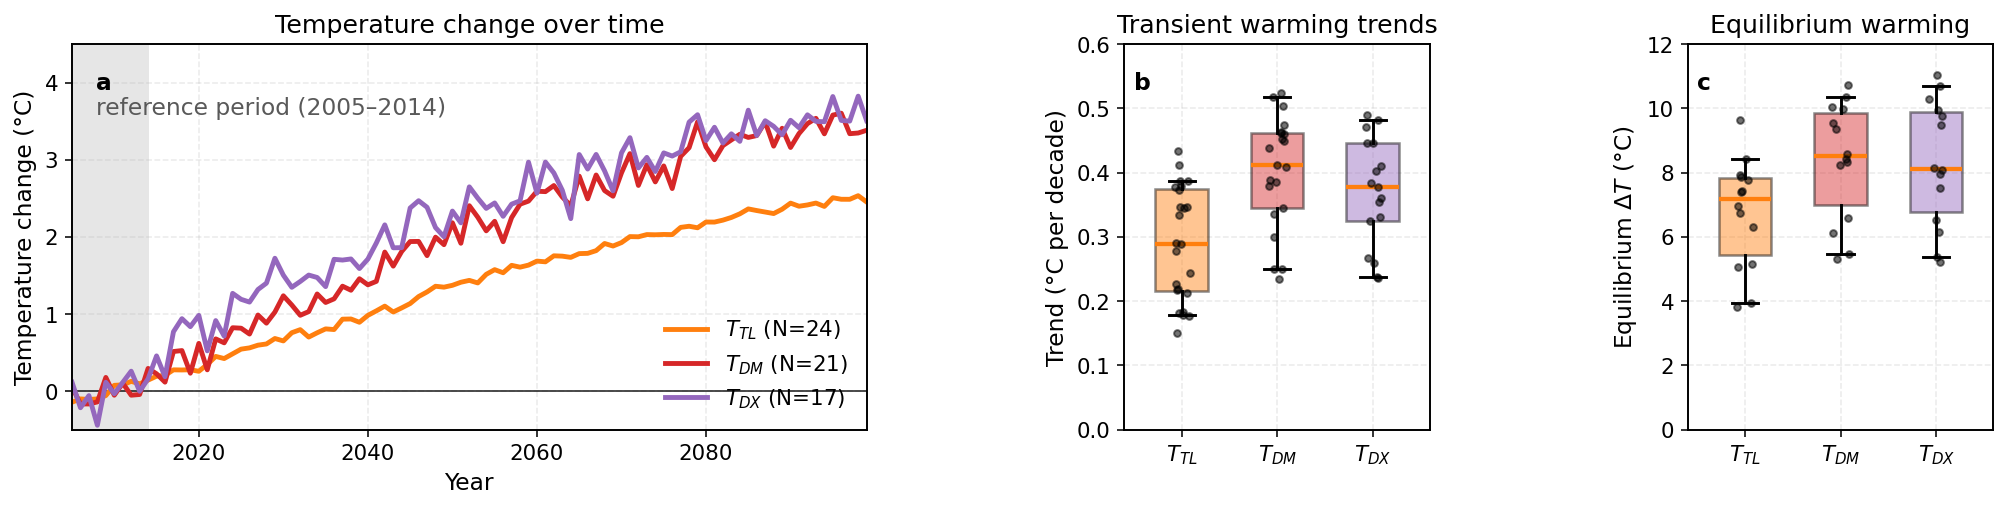

In [7]:
"""
FULL SCRIPT (UPDATED AGAIN):
✅ Panel (a) y-axis now extends to 5 °C
✅ Panel (a) y-ticks are whole numbers (…0,1,2,3,4,5…)
✅ Panel (b,c) y-ticks also forced to “nice” whole/clean spacing (0.1 in b, 2 in c)
✅ Keeps the updated model availability logic:
   - Panels (a,b): SSP full availability lists (TTL/TDM=36, TDX=30 if files exist)
   - Panel (c): equilibrium subset (abrupt ∩ piControl), then optional drop >12°C

Celsius everywhere (Kelvin->°C safeguard) + improved spacing.
✅ NEW: Panel A "reference period" label moved below the "a" label (axes coords)
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.ticker import MultipleLocator
from pathlib import Path

# ============================ USER SETTINGS ============================
OUTDIR = Path("/content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist")  # <-- CHANGE if needed
FIG_OUT = OUTDIR / "fig2_threepanel_SSPfull_equilsubset_C_yTicksFixed.png"

REFERENCE_PERIOD = (2005, 2014)
TREND_YEARS = (2015, 2099)
ABRUPT_EQUIL_LAST_N_YEARS = 30

# Updated y-limits
YLIM_A = (-0.5, 4.5)   # panel a now to 5
YLIM_B = (0.0, 0.6)    # panel b
YLIM_C = (0.0, 12.0)   # panel c

# Tick spacing (to look like your reference)
YTICK_A = 1.0          # whole numbers
YTICK_B = 0.1          # clean decimals
YTICK_C = 2.0          # 0,2,4,...,12

# Panel (c) outlier exclusion threshold (optional)
EQUIL_MAX_C = 12.0
DROP_EQUIL_OUTLIERS = True  # drops only from panel (c)

# Colors
C_TTL = "tab:orange"
C_TDM = "tab:red"
C_TDX = "tab:purple"

# ============================ MODEL LISTS (FROM YOUR PRINTS) ============================

SSP_MODELS_TTL_TDM = [
    "ACCESS-CM2","AWI-CM-1-1-MR","BCC-CSM2-MR","CAMS-CSM1-0","CESM2","CESM2-WACCM",
    "CMCC-CM2-SR5","CMCC-ESM2","CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5",
    "EC-Earth3","EC-Earth3-CC","EC-Earth3-Veg","EC-Earth3-Veg-LR","FGOALS-g3","GFDL-CM4",
    "GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM","INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR",
    "KACE-1-0-G","KIOST-ESM","MIROC-ES2L","MIROC6","MPI-ESM1-2-HR","MPI-ESM1-2-LR",
    "MRI-ESM2-0","NESM3","NorESM2-LM","NorESM2-MM","TaiESM1","UKESM1-0-LL"
]

SSP_MODELS_TDX = [
    "ACCESS-CM2","AWI-CM-1-1-MR","BCC-CSM2-MR","CAMS-CSM1-0","CMCC-ESM2","CNRM-CM6-1",
    "CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC","EC-Earth3-Veg","EC-Earth3-Veg-LR",
    "FGOALS-g3","GFDL-CM4","GFDL-ESM4","GISS-E2-1-G","INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR",
    "KACE-1-0-G","KIOST-ESM","MIROC-ES2L","MIROC6","MPI-ESM1-2-HR","MPI-ESM1-2-LR",
    "MRI-ESM2-0","NESM3","NorESM2-LM","NorESM2-MM","TaiESM1"
]

EQUIL_MODELS = [
    "ACCESS-CM2","AWI-CM-1-1-MR","CMCC-ESM2","CNRM-CM6-1","CNRM-ESM2-1","CanESM5",
    "EC-Earth3","GFDL-CM4","GFDL-ESM4","INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR",
    "MPI-ESM1-2-HR","MPI-ESM1-2-LR","NorESM2-LM","NorESM2-MM","TaiESM1"
]

# ============================ STYLE ============================
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 240,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.5,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

# ============================ HELPERS ============================
def looks_like_kelvin(arr: np.ndarray) -> bool:
    a = np.asarray(arr, dtype=float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return False
    return (np.nanpercentile(a, 5) > 150) and (np.nanpercentile(a, 95) > 150)

def to_celsius_np(arr: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr, dtype=float)
    if looks_like_kelvin(arr):
        return arr - 273.15
    return arr

def infer_years_for_experiment(exp: str, n: int) -> np.ndarray:
    exp = (exp or "").lower()
    if "ssp" in exp:
        return np.arange(2015, 2015 + n)
    if "historical" in exp:
        return np.arange(1850, 1850 + n)
    return np.arange(1, n + 1)

def load_metric_anystyle(metric: str, exp: str):
    out = {}

    # Style A
    if exp == "hist2005-2014+ssp245":
        for p in OUTDIR.glob(f"*hist2005-2014+ssp245_{metric}.npy"):
            model = p.name.split("_hist2005-2014+ssp245_")[0]
            vals = to_celsius_np(np.load(p))
            years_path = OUTDIR / f"{model}_hist2005-2014+ssp245_{metric}_years.npy"
            if years_path.exists():
                yrs = np.load(years_path).astype(int)
            else:
                yrs = infer_years_for_experiment("ssp245", len(vals))
            out[model] = (yrs, vals)
        return out

    # Style B
    for p in OUTDIR.glob(f"*_{exp}_{metric}.npy"):
        model = p.name[:-4].rsplit("_", 2)[0]
        vals = to_celsius_np(np.load(p))
        years_path = OUTDIR / f"{model}_{exp}_{metric}_years.npy"
        if years_path.exists():
            yrs = np.load(years_path).astype(int)
        else:
            yrs = infer_years_for_experiment(exp, len(vals))
        out[model] = (yrs, vals)

    return out

def filter_to_models(d, models):
    keep = set(models)
    return {m: d[m] for m in d.keys() if m in keep}

def anomaly(values: np.ndarray, years: np.ndarray, ref=(2005, 2014)) -> np.ndarray:
    years = np.asarray(years, dtype=int)
    values = np.asarray(values, dtype=float)
    mask = (years >= ref[0]) & (years <= ref[1])
    if mask.sum() == 0:
        raise ValueError("Reference period not found in provided years array.")
    return values - np.nanmean(values[mask])

def common_years(dict_model_to_yv):
    common = None
    for _, (yrs, _) in dict_model_to_yv.items():
        s = set(np.asarray(yrs, dtype=int).tolist())
        common = s if common is None else (common & s)
    if common is None or len(common) == 0:
        return np.array([], dtype=int)
    return np.array(sorted(common), dtype=int)

def reindex_to_years(yrs, vals, target_years):
    yrs = np.asarray(yrs, dtype=int)
    vals = np.asarray(vals, dtype=float)
    out = np.full((len(target_years),), np.nan, dtype=float)
    idx = {int(y): i for i, y in enumerate(yrs)}
    for j, y in enumerate(target_years):
        i = idx.get(int(y), None)
        if i is not None:
            out[j] = vals[i]
    return out

def ensemble_mean_anomaly(dict_model_to_yv, ref=(2005, 2014)):
    yrs_common = common_years(dict_model_to_yv)
    if yrs_common.size == 0:
        return yrs_common, np.array([]), 0, np.empty((0, 0))

    mats = []
    used = 0
    for _, (yrs, vals) in dict_model_to_yv.items():
        v = reindex_to_years(yrs, vals, yrs_common)
        if np.all(~np.isfinite(v)):
            continue
        a = anomaly(v, yrs_common, ref=ref)
        mats.append(a)
        used += 1

    if used == 0:
        return yrs_common, np.array([]), 0, np.empty((0, len(yrs_common)))

    A = np.vstack(mats)
    return yrs_common, np.nanmean(A, axis=0), used, A

def slope_per_decade(years, y):
    years = np.asarray(years, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(years) & np.isfinite(y)
    if m.sum() < 5:
        return np.nan
    b1, _b0 = np.polyfit(years[m], y[m], 1)
    return 10.0 * b1

def transient_trends_across_models(dict_model_to_yv, ref=(2005, 2014), trend_years=(2015, 2099)):
    slopes = []
    for _, (yrs, vals) in dict_model_to_yv.items():
        yrs = np.asarray(yrs, dtype=int)
        vals = np.asarray(vals, dtype=float)
        try:
            a = anomaly(vals, yrs, ref=ref)
        except Exception:
            continue
        mask = (yrs >= trend_years[0]) & (yrs <= trend_years[1])
        if mask.sum() < 5:
            continue
        slopes.append(slope_per_decade(yrs[mask], a[mask]))
    slopes = np.asarray(slopes, dtype=float)
    slopes = slopes[np.isfinite(slopes)]
    return slopes, int(slopes.size)

def equilibrium_warming_by_model(dict_abrupt, dict_picontrol, last_n=30):
    out = {}
    common_models = sorted(set(dict_abrupt.keys()) & set(dict_picontrol.keys()))
    for m in common_models:
        _ya, va = dict_abrupt[m]
        _yp, vp = dict_picontrol[m]
        va = np.asarray(va, dtype=float)
        vp = np.asarray(vp, dtype=float)

        if np.isfinite(va).sum() < last_n:
            continue
        last = va[-last_n:]
        if np.isfinite(last).sum() < max(10, last_n // 2):
            continue
        if np.isfinite(vp).sum() < 10:
            continue

        out[m] = float(np.nanmean(last) - np.nanmean(vp))
    return out

def _boxplot(ax, data, color, pos, seed=0):
    data = np.asarray(data, dtype=float)
    bp = ax.boxplot(
        [data],
        positions=[pos],
        widths=0.55,
        whis=(5, 95),
        showfliers=False,
        patch_artist=True,
        medianprops={"linewidth": 2.2, "color": "tab:orange"},
        whiskerprops={"linewidth": 1.5},
        capprops={"linewidth": 1.5},
        boxprops={"linewidth": 1.3},
    )
    bp["boxes"][0].set_facecolor(color)
    bp["boxes"][0].set_alpha(0.45)

    rng = np.random.default_rng(seed + pos)
    x = np.full_like(data, pos, dtype=float) + (rng.random(data.size) - 0.5) * 0.18
    ax.scatter(x, data, s=12, color="k", alpha=0.55, zorder=3)

# ============================ PLOTTING ============================
def plot_figure2_threepanel(
    ttl_ts, tdm_ts, tdx_ts,
    ttl_abrupt, tdm_abrupt, tdx_abrupt,
    ttl_pi, tdm_pi, tdx_pi,
    ref=(2005, 2014),
    trend_years=(2015, 2099),
    savepath=None,
    show=True,
    ylim_a=(-0.5, 5.0),
    ylim_b=(0.0, 0.6),
    ylim_c=(0.0, 12.0),
    ytick_a=1.0,
    ytick_b=0.1,
    ytick_c=2.0,
):
    yrs, ttl_mean, n_ttl, _ = ensemble_mean_anomaly(ttl_ts, ref=ref)
    _,   tdm_mean, n_tdm, _ = ensemble_mean_anomaly(tdm_ts, ref=ref)
    _,   tdx_mean, n_tdx, _ = ensemble_mean_anomaly(tdx_ts, ref=ref)

    ttl_tr, _ = transient_trends_across_models(ttl_ts, ref=ref, trend_years=trend_years)
    tdm_tr, _ = transient_trends_across_models(tdm_ts, ref=ref, trend_years=trend_years)
    tdx_tr, _ = transient_trends_across_models(tdx_ts, ref=ref, trend_years=trend_years)

    eq_TTL = equilibrium_warming_by_model(ttl_abrupt, ttl_pi, last_n=ABRUPT_EQUIL_LAST_N_YEARS)
    eq_TDM = equilibrium_warming_by_model(tdm_abrupt, tdm_pi, last_n=ABRUPT_EQUIL_LAST_N_YEARS)
    eq_TDX = equilibrium_warming_by_model(tdx_abrupt, tdx_pi, last_n=ABRUPT_EQUIL_LAST_N_YEARS)

    ttl_eq = np.array(list(eq_TTL.values()), dtype=float)
    tdm_eq = np.array(list(eq_TDM.values()), dtype=float)
    tdx_eq = np.array(list(eq_TDX.values()), dtype=float)

    # Geometry + spacing
    fig = plt.figure(figsize=(14.6, 4.05), dpi=140)
    gs = gridspec.GridSpec(1, 3, width_ratios=[2.6, 1.0, 1.0])
    axA = fig.add_subplot(gs[0, 0])
    axB = fig.add_subplot(gs[0, 1])
    axC = fig.add_subplot(gs[0, 2])
    fig.subplots_adjust(left=0.055, right=0.995, bottom=0.18, top=0.86, wspace=0.55)

    # ---- Panel a ----
    axA.axhline(0, color="k", lw=1, alpha=0.7)
    axA.axvspan(ref[0], ref[1], color="0.9", zorder=0)

    axA.plot(yrs, ttl_mean, color=C_TTL, label=rf"$T_{{TL}}$ (N={n_ttl})")
    axA.plot(yrs, tdm_mean, color=C_TDM, label=rf"$T_{{DM}}$ (N={n_tdm})")
    axA.plot(yrs, tdx_mean, color=C_TDX, label=rf"$T_{{DX}}$ (N={n_tdx})")

    axA.set_title("Temperature change over time")
    axA.set_xlabel("Year")
    axA.set_ylabel("Temperature change (°C)")
    if yrs.size > 0:
        axA.set_xlim(int(yrs.min()), int(yrs.max()))
    axA.set_ylim(*ylim_a)
    axA.yaxis.set_major_locator(MultipleLocator(ytick_a))  # whole numbers

    # Panel label + reference label (axes coords so it stays put)
    axA.text(0.03, 0.93, "a", transform=axA.transAxes, fontweight="bold",
             ha="left", va="top")
    axA.text(0.03, 0.865, f"reference period ({ref[0]}–{ref[1]})",
             transform=axA.transAxes, color="0.35",
             ha="left", va="top")

    axA.legend(frameon=False, loc="lower right")

    # ---- Panel b ----
    axB.set_title("Transient warming trends")
    _boxplot(axB, ttl_tr, C_TTL, 1, seed=7)
    _boxplot(axB, tdm_tr, C_TDM, 2, seed=7)
    _boxplot(axB, tdx_tr, C_TDX, 3, seed=7)
    axB.set_xticks([1, 2, 3], [r"$T_{TL}$", r"$T_{DM}$", r"$T_{DX}$"])
    axB.set_ylabel("Trend (°C per decade)")
    axB.set_xlim(0.4, 3.6)
    axB.set_ylim(*ylim_b)
    axB.yaxis.set_major_locator(MultipleLocator(ytick_b))
    axB.text(0.03, 0.93, "b", transform=axB.transAxes, fontweight="bold", ha="left", va="top")

    # ---- Panel c ----
    axC.set_title(r"Equilibrium warming")
    _boxplot(axC, ttl_eq, C_TTL, 1, seed=11)
    _boxplot(axC, tdm_eq, C_TDM, 2, seed=11)
    _boxplot(axC, tdx_eq, C_TDX, 3, seed=11)
    axC.set_xticks([1, 2, 3], [r"$T_{TL}$", r"$T_{DM}$", r"$T_{DX}$"])
    axC.set_ylabel(r"Equilibrium $\Delta T$ (°C)")
    axC.set_xlim(0.4, 3.6)
    axC.set_ylim(*ylim_c)
    axC.yaxis.set_major_locator(MultipleLocator(ytick_c))
    axC.text(0.03, 0.93, "c", transform=axC.transAxes, fontweight="bold", ha="left", va="top")

    for ax in (axA, axB, axC):
        for sp in ax.spines.values():
            sp.set_linewidth(1.0)

    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight", pad_inches=0.02)
        print("Saved:", savepath)

    if show:
        plt.show()
    else:
        plt.close(fig)

# ============================ LOAD DATA ============================

TTL_ts = load_metric_anystyle("TTL", exp="hist2005-2014+ssp245")
TDM_ts = load_metric_anystyle("TDM", exp="hist2005-2014+ssp245")
TDX_ts = load_metric_anystyle("TDX", exp="hist2005-2014+ssp245")

if len(TTL_ts) == 0:
    print("No concatenated hist2005-2014+ssp245 files found; falling back to ssp245-only (ref may fail).")
    TTL_ts = load_metric_anystyle("TTL", exp="ssp245")
    TDM_ts = load_metric_anystyle("TDM", exp="ssp245")
    TDX_ts = load_metric_anystyle("TDX", exp="ssp245")

TTL_abrupt = load_metric_anystyle("TTL", exp="abrupt-4xCO2")
TDM_abrupt = load_metric_anystyle("TDM", exp="abrupt-4xCO2")
TDX_abrupt = load_metric_anystyle("TDX", exp="abrupt-4xCO2")

TTL_pi = load_metric_anystyle("TTL", exp="piControl")
TDM_pi = load_metric_anystyle("TDM", exp="piControl")
TDX_pi = load_metric_anystyle("TDX", exp="piControl")

# ============================ APPLY MODEL AVAILABILITY RULES ============================

# Panels (a,b): SSP full sets (big N), metric-specific
TTL_ts = filter_to_models(TTL_ts, SSP_MODELS_TTL_TDM)
TDM_ts = filter_to_models(TDM_ts, SSP_MODELS_TTL_TDM)
TDX_ts = filter_to_models(TDX_ts, SSP_MODELS_TDX)

print("Loaded counts for SSP panels (a,b):")
print("  TTL:", len(TTL_ts), "expected ~36 (if files exist)")
print("  TDM:", len(TDM_ts), "expected ~36 (if files exist)")
print("  TDX:", len(TDX_ts), "expected ~30 (if files exist)")

# Panel (c): equilibrium subset + enforce abrupt∩piControl matching
TTL_abrupt = filter_to_models(TTL_abrupt, EQUIL_MODELS)
TDM_abrupt = filter_to_models(TDM_abrupt, EQUIL_MODELS)
TDX_abrupt = filter_to_models(TDX_abrupt, EQUIL_MODELS)

TTL_pi = filter_to_models(TTL_pi, EQUIL_MODELS)
TDM_pi = filter_to_models(TDM_pi, EQUIL_MODELS)
TDX_pi = filter_to_models(TDX_pi, EQUIL_MODELS)

TTL_common = sorted(set(TTL_abrupt.keys()) & set(TTL_pi.keys()))
TDM_common = sorted(set(TDM_abrupt.keys()) & set(TDM_pi.keys()))
TDX_common = sorted(set(TDX_abrupt.keys()) & set(TDX_pi.keys()))

TTL_abrupt = filter_to_models(TTL_abrupt, TTL_common); TTL_pi = filter_to_models(TTL_pi, TTL_common)
TDM_abrupt = filter_to_models(TDM_abrupt, TDM_common); TDM_pi = filter_to_models(TDM_pi, TDM_common)
TDX_abrupt = filter_to_models(TDX_abrupt, TDX_common); TDX_pi = filter_to_models(TDX_pi, TDX_common)

print("Loaded counts for equilibrium panel (c) AFTER matching abrupt∩piControl:")
print("  TTL:", len(TTL_common))
print("  TDM:", len(TDM_common))
print("  TDX:", len(TDX_common))

# ============================ PANEL (c) OUTLIER CHECK / DROP (> 12°C) ============================

eq_TTL = equilibrium_warming_by_model(TTL_abrupt, TTL_pi, last_n=ABRUPT_EQUIL_LAST_N_YEARS)
eq_TDM = equilibrium_warming_by_model(TDM_abrupt, TDM_pi, last_n=ABRUPT_EQUIL_LAST_N_YEARS)
eq_TDX = equilibrium_warming_by_model(TDX_abrupt, TDX_pi, last_n=ABRUPT_EQUIL_LAST_N_YEARS)

bad_models = set()
for name, eq in [("TTL", eq_TTL), ("TDM", eq_TDM), ("TDX", eq_TDX)]:
    bad_here = sorted([m for m, v in eq.items() if np.isfinite(v) and v > EQUIL_MAX_C])
    if bad_here:
        print(f"[Panel c] {name} models with ΔT_eq > {EQUIL_MAX_C:.1f}°C:", bad_here)
    bad_models |= set(bad_here)

bad_models = sorted(bad_models)
print(f"[Panel c] Union of models exceeding {EQUIL_MAX_C:.1f}°C in any metric:", bad_models)

if DROP_EQUIL_OUTLIERS and len(bad_models) > 0:
    for m in bad_models:
        TTL_abrupt.pop(m, None); TDM_abrupt.pop(m, None); TDX_abrupt.pop(m, None)
        TTL_pi.pop(m, None);     TDM_pi.pop(m, None);     TDX_pi.pop(m, None)
    print("[Panel c] Dropped outliers from equilibrium panel only.")

print("Final counts used in panel (c):")
print("  TTL:", len(TTL_abrupt), "TDM:", len(TDM_abrupt), "TDX:", len(TDX_abrupt))

# ============================ PLOT ============================
plot_figure2_threepanel(
    TTL_ts, TDM_ts, TDX_ts,
    TTL_abrupt, TDM_abrupt, TDX_abrupt,
    TTL_pi, TDM_pi, TDX_pi,
    ref=REFERENCE_PERIOD,
    trend_years=TREND_YEARS,
    savepath=FIG_OUT,
    show=True,
    ylim_a=YLIM_A,
    ylim_b=YLIM_B,
    ylim_c=YLIM_C,
    ytick_a=YTICK_A,
    ytick_b=YTICK_B,
    ytick_c=YTICK_C,
)



[info] Common models used (ALLOWED ∩ available, N=19):
['ACCESS-CM2', 'AWI-CM-1-1-MR', 'CAMS-CSM1-0', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-ESM2-1', 'CanESM5', 'EC-Earth3', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'GFDL-CM4', 'GFDL-ESM4', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1']


/tmp/ipython-input-2023999022.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


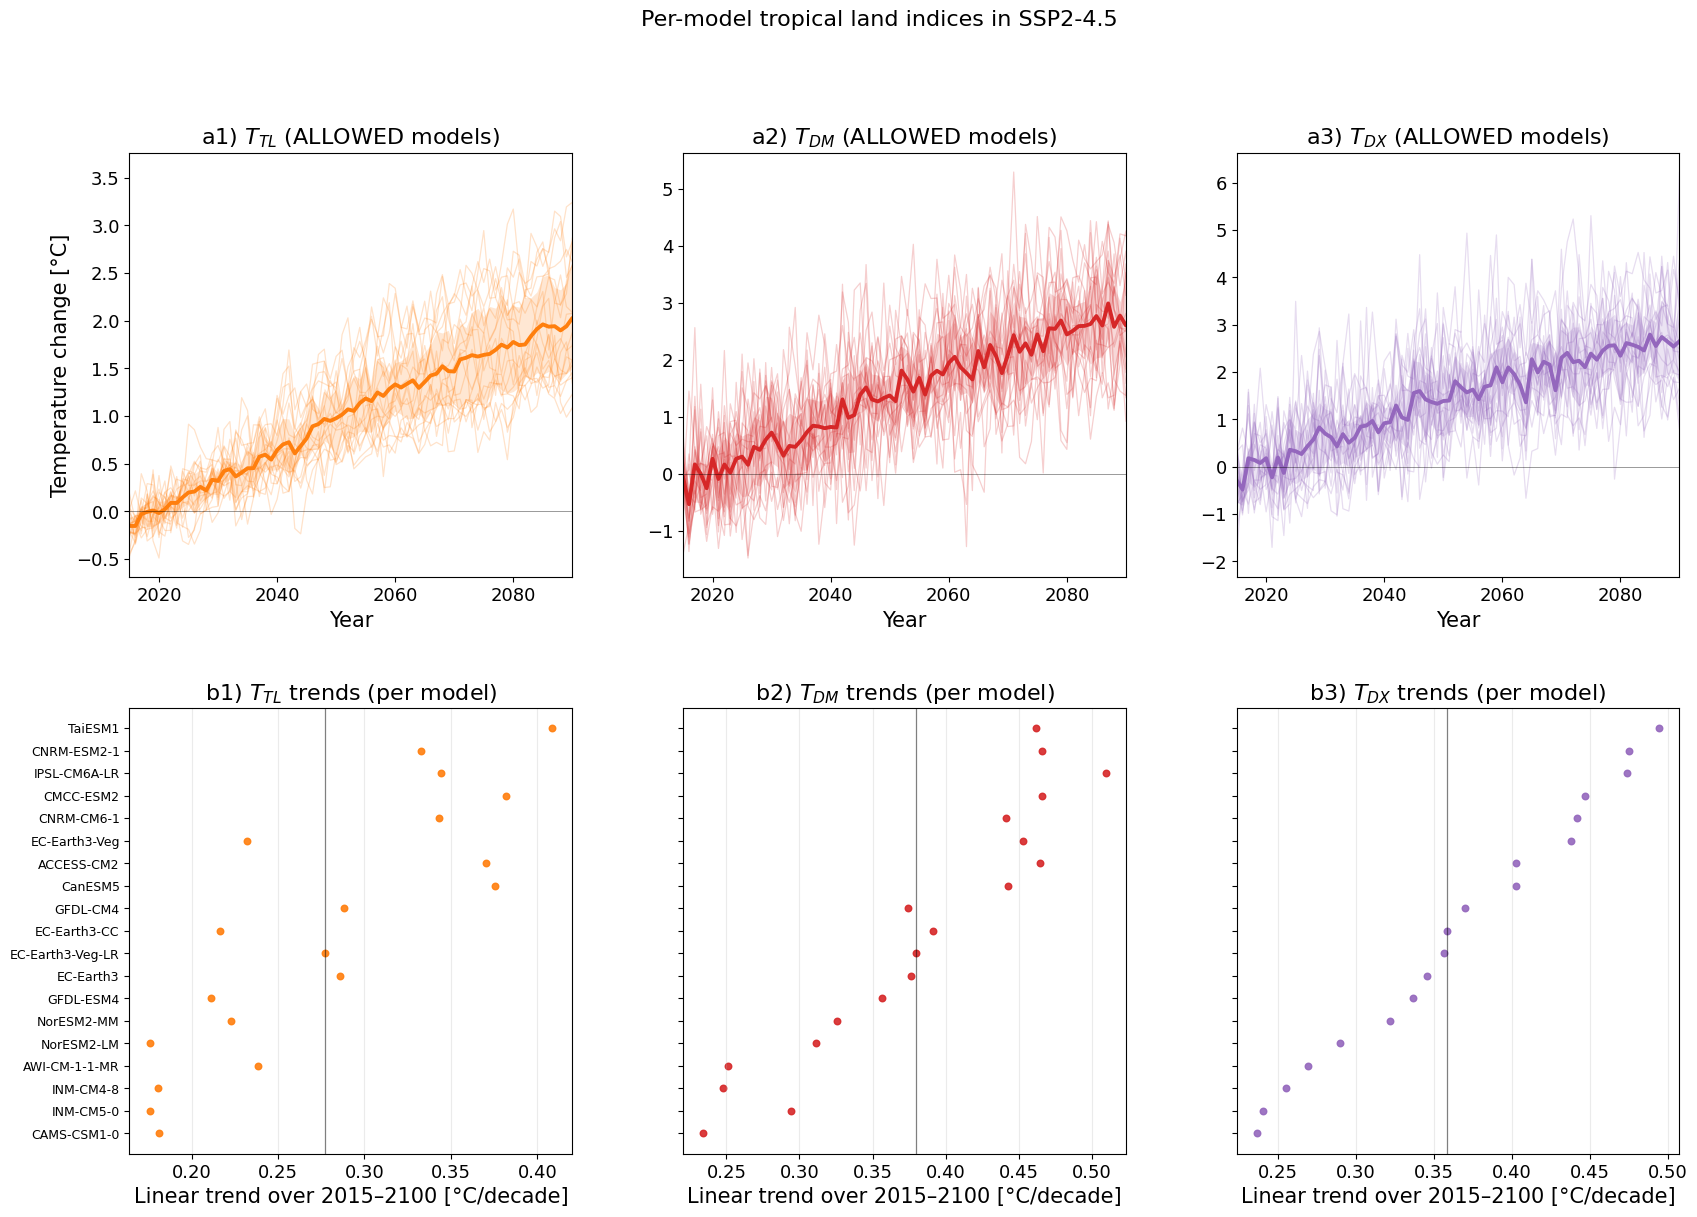

[saved] /content/drive/MyDrive/cmip6_extreme_hot_days/figures/figS_per_model_TL_TDM_TDX_spaghetti_and_trends_ALLOWED.png


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# REQUIREMENTS (you already have these loaded):
#   TTL_s, TDM_s, TDX_s
# each is a dict: model_name -> 1D array (time series, typically 2015..2100)
# ============================================================

# =========================
# USER SETTINGS
# =========================
OUTDIR   = "/content/drive/MyDrive/cmip6_extreme_hot_days/figures"  # change if needed
OUTNAME  = "figS_per_model_TL_TDM_TDX_spaghetti_and_trends_ALLOWED.png"

START_YEAR = 2015
XLIM = (2015, 2090)
XTICKS = [2020, 2040, 2060, 2080]

# Baseline for anomalies (since SSP2-4.5 usually starts 2015): use first 10 years (2015–2024)
BASE_FIRST_N_YEARS = 10

# ---- YOUR ALLOWED LIST (edit to match your paper) ----
ALLOWED = sorted({
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-LM","NorESM2-MM","TaiESM1"
})

# Styling
LW_MODEL = 0.9
ALPHA_MODEL = 0.22
LW_MMM = 2.8
ALPHA_IQR = 0.18

# Use your earlier “nice” colors (orange, red, purple)
cs = [(255/255,127/255,14/255), (214/255,39/255,40/255), (148/255,103/255,189/255)]

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13
})

os.makedirs(OUTDIR, exist_ok=True)
OUTPNG = os.path.join(OUTDIR, OUTNAME)

# =========================
# HELPERS
# =========================
def maybe_K_to_C(arr):
    arr = np.asarray(arr, dtype=float)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return arr
    if np.nanmedian(finite) > 150:
        return arr - 273.15
    return arr

def infer_years_from_length(n, start_year=2015):
    return np.arange(start_year, start_year + int(n), dtype=int)

def build_matrix_from_value_dict(d, models, start_year=2015):
    lengths = {m: len(np.asarray(d[m])) for m in models}
    maxlen = max(lengths.values()) if lengths else 0
    yrs = infer_years_from_length(maxlen, start_year=start_year)

    M = np.full((len(models), maxlen), np.nan, dtype=float)
    for i, m in enumerate(models):
        v = maybe_K_to_C(d[m])
        n = len(v)
        M[i, :n] = v
    return yrs, M

def to_anom_first_n_years(M, n0=10):
    n0 = min(n0, M.shape[1])
    base = np.nanmean(M[:, :n0], axis=1, keepdims=True)
    return M - base

def mean_iqr(A):
    mme = np.nanmean(A, axis=0)
    q25 = np.nanpercentile(A, 25, axis=0)
    q75 = np.nanpercentile(A, 75, axis=0)
    return mme, q25, q75

def per_model_trend_decade(yrs, A):
    x = yrs.astype(float)
    slopes = np.full(A.shape[0], np.nan, dtype=float)
    for i in range(A.shape[0]):
        y = A[i, :]
        mask = np.isfinite(y) & np.isfinite(x)
        if mask.sum() < 10:
            continue
        b = np.polyfit(x[mask], y[mask], 1)[0]
        slopes[i] = 10.0 * b
    return slopes

# =========================
# COMMON MODEL SET (ALLOWED-only)
# =========================
common_models = sorted(list(set(ALLOWED) & set(TTL_s.keys()) & set(TDM_s.keys()) & set(TDX_s.keys())))
N = len(common_models)
print(f"[info] Common models used (ALLOWED ∩ available, N={N}):")
print(common_models)

if N == 0:
    raise RuntimeError("No common models found after filtering by ALLOWED. Check ALLOWED names vs dict keys.")

# =========================
# BUILD MATRICES (°C), MAKE ANOMALIES
# =========================
yrs, TTL_mat = build_matrix_from_value_dict(TTL_s, common_models, start_year=START_YEAR)
_,   TDM_mat = build_matrix_from_value_dict(TDM_s, common_models, start_year=START_YEAR)
_,   TDX_mat = build_matrix_from_value_dict(TDX_s, common_models, start_year=START_YEAR)

TTL_anom = to_anom_first_n_years(TTL_mat, BASE_FIRST_N_YEARS)
TDM_anom = to_anom_first_n_years(TDM_mat, BASE_FIRST_N_YEARS)
TDX_anom = to_anom_first_n_years(TDX_mat, BASE_FIRST_N_YEARS)

# MMM + IQR
ttl_m, ttl_q25, ttl_q75 = mean_iqr(TTL_anom)
tdm_m, tdm_q25, tdm_q75 = mean_iqr(TDM_anom)
tdx_m, tdx_q25, tdx_q75 = mean_iqr(TDX_anom)

# Per-model trends (°C/decade)
ttl_sl = per_model_trend_decade(yrs, TTL_anom)
tdm_sl = per_model_trend_decade(yrs, TDM_anom)
tdx_sl = per_model_trend_decade(yrs, TDX_anom)

# Sort models by TDX trend
order = np.argsort(tdx_sl)
models_sorted = [common_models[i] for i in order]
ttl_sl_s = ttl_sl[order]
tdm_sl_s = tdm_sl[order]
tdx_sl_s = tdx_sl[order]

# =========================
# FIGURE: top row spaghetti; bottom row per-model trends
# =========================
fig = plt.figure(figsize=(20, 13))
gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.05], hspace=0.30, wspace=0.25)

def spaghetti_panel(ax, A_anom, mmm, q25, q75, color, title):
    for i in range(A_anom.shape[0]):
        ax.plot(yrs, A_anom[i, :], color=color, lw=LW_MODEL, alpha=ALPHA_MODEL)
    ax.fill_between(yrs, q25, q75, color=color, alpha=ALPHA_IQR, lw=0)
    ax.plot(yrs, mmm, color=color, lw=LW_MMM)
    ax.axhline(0, color="k", lw=0.7, alpha=0.4)
    ax.set_title(title)
    ax.set_xlim(XLIM)
    ax.set_xticks(XTICKS)
    ax.set_xlabel("Year")

def trend_dotpanel(ax, slopes, title, color, show_ylabels=False):
    y = np.arange(len(models_sorted))
    ax.scatter(slopes, y, s=22, color=color, alpha=0.9)
    ax.axvline(np.nanmedian(slopes), color="k", lw=0.9, alpha=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(models_sorted if show_ylabels else [], fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("Linear trend over 2015–2100 [°C/decade]")
    ax.grid(True, axis="x", alpha=0.25)

# Top row
ax1 = fig.add_subplot(gs[0, 0]); spaghetti_panel(ax1, TTL_anom, ttl_m, ttl_q25, ttl_q75, cs[0], r"a1) $T_{TL}$ (ALLOWED models)")
ax2 = fig.add_subplot(gs[0, 1]); spaghetti_panel(ax2, TDM_anom, tdm_m, tdm_q25, tdm_q75, cs[1], r"a2) $T_{DM}$ (ALLOWED models)")
ax3 = fig.add_subplot(gs[0, 2]); spaghetti_panel(ax3, TDX_anom, tdx_m, tdx_q25, tdx_q75, cs[2], r"a3) $T_{DX}$ (ALLOWED models)")
ax1.set_ylabel("Temperature change [°C]")

# Bottom row
ax4 = fig.add_subplot(gs[1, 0]); trend_dotpanel(ax4, ttl_sl_s, r"b1) $T_{TL}$ trends (per model)", cs[0], show_ylabels=True)
ax5 = fig.add_subplot(gs[1, 1]); trend_dotpanel(ax5, tdm_sl_s, r"b2) $T_{DM}$ trends (per model)", cs[1], show_ylabels=False)
ax6 = fig.add_subplot(gs[1, 2]); trend_dotpanel(ax6, tdx_sl_s, r"b3) $T_{DX}$ trends (per model)", cs[2], show_ylabels=False)

fig.suptitle(
    f"Per-model tropical land indices in SSP2-4.5",
    y=0.99, fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUTPNG, dpi=300, bbox_inches="tight")
plt.show()

print("[saved]", OUTPNG)
